## TP entrainement IA

https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset


## Intsallation des dépendances


In [ ]:
!pip install scikit-learn seaborn pandas matplotlib joblib fastapi uvicorn

In [2]:
import seaborn as sns, pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv('../data/gym_members_exercise_tracking.csv')
print(df.shape) 
print(df.isnull().sum()) 
df['Experience_Level'].value_counts()
df.head()


(973, 15)
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## Nettoyage et encodage

- Nous avons beaucoup de données sur les statistiques de sportifs, elles sont remplies à 100%
- Classées en 3 niveaux d'expériences

Nous allons garder seulement 4 colonnes pour l'entrainement:

Age, BMI , Workout_Frequency (days/week), Session_Duration (hours)
- Ce sont des données que l'on pourra facilement demander aux futurs utilisateurs de l'application


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df.dropna() 
FEATURES = ['Age','Workout_Frequency (days/week)','BMI','Session_Duration (hours)']
X = df[FEATURES]
le = LabelEncoder() # Beginner=0 Intermediate=1 Advanced=2
# Identifier les colonnes numériques et catégorielles
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

y = le.fit_transform(df['Experience_Level'])
print('Classes :', le.classes_)
# 80% train / 20% test, stratifié (équilibre des classes conservé)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Classes : [1 2 3]
Train: 778 | Test: 195


## Entrainner le modème

In [4]:
# Cellule 3 — Entraînement selon tous les modèles
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
models = {
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN':                 KNeighborsClassifier(),
    'SVM':                 SVC(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'{name}: {accuracy_score(y_test, y_pred):.3f}')


Random Forest: 0.913
Gradient Boosting: 0.887
Logistic Regression: 0.882
KNN: 0.605
SVM: 0.492
Decision Tree: 0.862


## Choix du model
- Nous allons choisir le random forest comme algorithme car il présente les meilleurs résultats

In [5]:
!mlflow ui --port 3005

/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[2026-06-07 19:38:33 +0200] [59262] [INFO] Starting gunicorn 23.0.0
[2026-06-07 19:38:33 +0200] [59262] [ERROR] Connection in use: ('127.0.0.1', 3005)
[2026-06-07 19:38:33 +0200] [59262] [ERROR] connection to ('127.0.0.1', 3005) failed: [Errno 48] Address already in use
[2026-06-07 19:38:34 +0200] [59262] [ERROR] Connection in use: ('127.0.0.1', 3005)
[2026-06-07 19:38:34 +0200] [59262] [ERROR] connection to ('127.0.0.1', 3005) failed: [Errno 48] Address already in use
[2026-06-07 19:38:35 +0200] [59262] [ERROR] Connection in use: ('127.0.0.1', 3005)
[2026-06-07 19:38:35 +0200] [59262] [ERROR] connection to ('127.0.0.1', 3005) failed: [Errno 48] Address already in use
[2026-06-07 19:38:36 +0200]

In [6]:
import mlflow


mlflow.set_tracking_uri('../mlruns')          # stockage local
mlflow.set_experiment('gym-ml-experience-level')

print('Tracking URI :', mlflow.get_tracking_uri())
print('Expérience   :', mlflow.get_experiment_by_name('gym-ml-experience-level'))

/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Tracking URI : ../mlruns
Expérience   : <Experiment: artifact_location='/Users/victorboyadjian/Documents/dev/TP_ML/notebooks/../mlruns/481336339433266820', creation_time=1780849445745, experiment_id='481336339433266820', last_update_time=1780849445745, lifecycle_stage='active', name='gym-ml-experience-level', tags={}>


In [7]:
# Cellule 3 — Entraînement
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}') # ~0.985
print(classification_report(y_test, y_pred, target_names=['Débutant', 'Intermédiaire', 'Avancé']))

Accuracy : 0.913
               precision    recall  f1-score   support

     Débutant       0.90      0.87      0.88        75
Intermédiaire       0.88      0.91      0.90        82
       Avancé       1.00      1.00      1.00        38

     accuracy                           0.91       195
    macro avg       0.93      0.93      0.93       195
 weighted avg       0.91      0.91      0.91       195



In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, FEATURES), # ou numerical_features
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessor créé :')
print(preprocessor)

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__max_features':      ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print('\nMeilleurs paramètres RF :', rf_grid.best_params_)
print(f'Meilleur score CV RF   : {rf_grid.best_score_:.4f}')

Preprocessor créé :
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Workout_Frequency (days/week)', 'BMI',
                                  'Session_Duration (hours)']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 [])])
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Meilleurs paramètres RF : {'clf__ma

## Confusion matrix

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


def evaluate_model(name, model, X_train, y_train, X_test, y_test, class_names=None):
    """Affiche toutes les métriques pour un modèle entraîné."""
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  Accuracy Test : {acc:.4f}')
    print()
    print('--- Classification Report ---')
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix — {name}')

    # Normalized
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
    disp_norm = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names)
    disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
    axes[1].set_title(f'Confusion Matrix (normalisée) — {name}')

    plt.tight_layout()
    fname = name.replace(' ', '_').lower()
    plt.savefig(f'../figures/cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred


  Random Forest (GridSearch)
  Accuracy Test : 0.9128

--- Classification Report ---
               precision    recall  f1-score   support

     Débutant       0.90      0.87      0.88        75
Intermédiaire       0.88      0.91      0.90        82
       Avancé       1.00      1.00      1.00        38

     accuracy                           0.91       195
    macro avg       0.93      0.93      0.93       195
 weighted avg       0.91      0.91      0.91       195



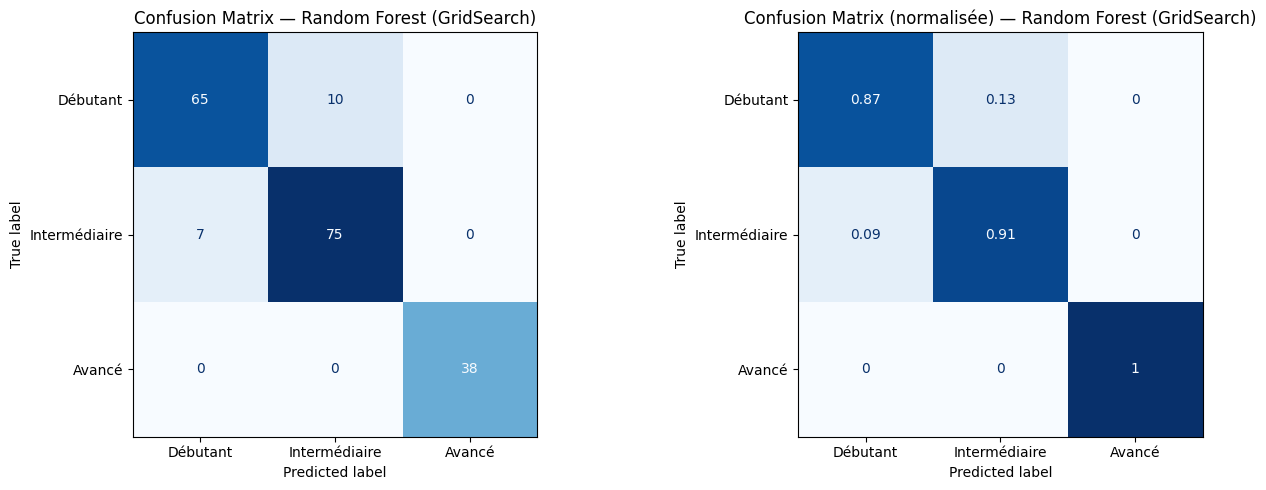

In [10]:
class_names = ['Débutant', 'Intermédiaire', 'Avancé']

test_results = {}
acc, preds = evaluate_model('Random Forest (GridSearch)', rf_grid.best_estimator_, X_train, y_train, X_test, y_test, class_names)
test_results['Random Forest (GridSearch)'] = acc

## Feature importance

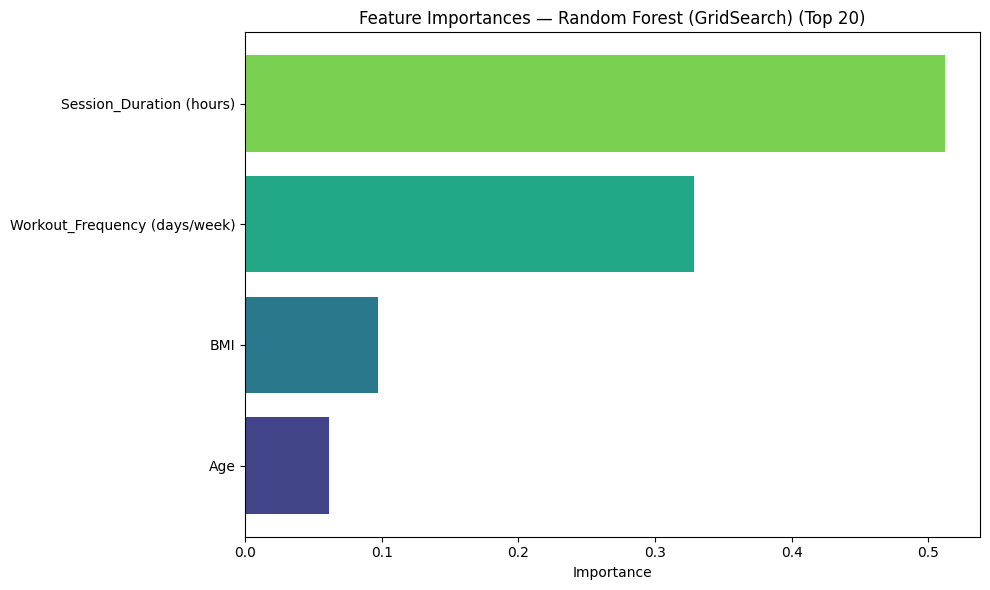

,feature,importance
0,Age,0.061515
2,BMI,0.097500
1,Workout_Frequency (days/week),0.328654
3,Session_Duration (hours),0.512332


In [11]:
def plot_feature_importances(name, pipeline, numerical_features, categorical_features, top_n=20):
    """Extrait et visualise les feature importances d'un pipeline sklearn."""
    clf = pipeline.named_steps['clf']
    prep = pipeline.named_steps['prep']

    if not hasattr(clf, 'feature_importances_'):
        print(f'{name} ne supporte pas feature_importances_')
        return

    # Reconstruire les noms de features après OneHotEncoding
    cat_feature_names = []
    if categorical_features:
        ohe = prep.named_transformers_['cat'].named_steps['onehot']
        cat_feature_names = list(ohe.get_feature_names_out(categorical_features))

    feature_names = numerical_features + cat_feature_names
    importances   = clf.feature_importances_

    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(6, len(fi_df) * 0.4)))
    colors = sns.color_palette('viridis', len(fi_df))
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors)
    ax.set_title(f'Feature Importances — {name} (Top {top_n})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    fname = name.replace(' ', '_').replace('(','').replace(')','').lower()
    plt.savefig(f'../figures/fi_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fi_df

plot_feature_importances('Random Forest (GridSearch)', rf_grid.best_estimator_, FEATURES, categorical_features)

- Les échelles sont assez élevés dans le dataset pour proposer un niveau expert. Il faut souvent avoir 4 sessions de sport par semaine pour être un niveau élevé. 

- Pour une application orientée amateurs qui recommande des exercices pour progresser, il serait peut être pertinent d'avoir des échelles plus basses pour recommander un niveau élevé. 

## Learning curves

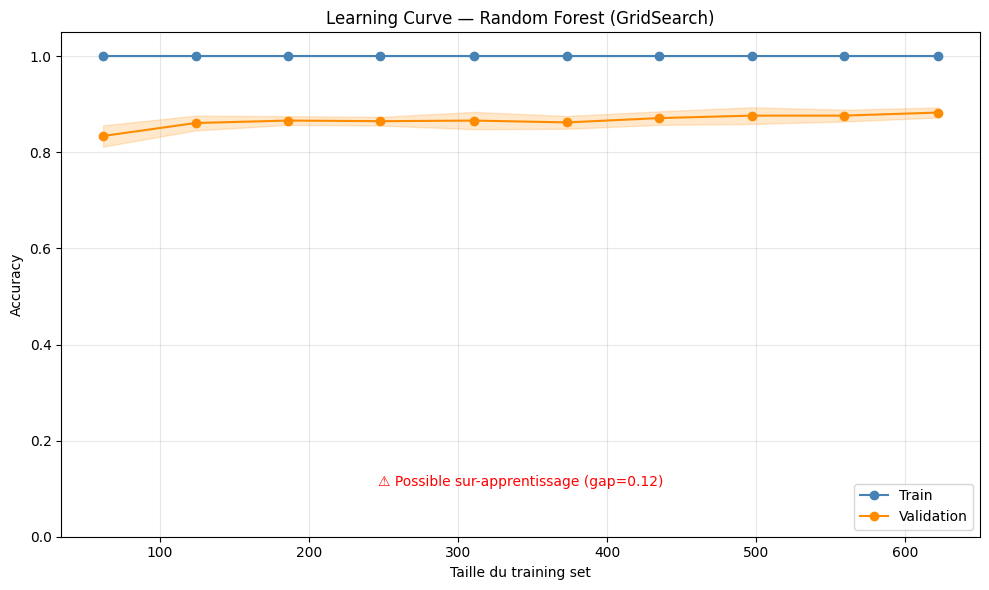

In [12]:
from sklearn.model_selection import learning_curve


def plot_learning_curve(name, pipeline, X, y, cv=5, n_jobs=-1):
    """Trace la learning curve d'un modèle (biais/variance)."""
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='steelblue')

    ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='darkorange')

    ax.set_title(f'Learning Curve — {name}')
    ax.set_xlabel('Taille du training set')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    # Annotation biais/variance
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        ax.text(0.5, 0.1, f'⚠ Possible sur-apprentissage (gap={gap:.2f})',
                transform=ax.transAxes, ha='center', color='red')
    elif val_mean[-1] < 0.7:
        ax.text(0.5, 0.1, f'⚠ Possible sous-apprentissage (val={val_mean[-1]:.2f})',
                transform=ax.transAxes, ha='center', color='red')
    else:
        ax.text(0.5, 0.05, f'Bon équilibre biais/variance',
                transform=ax.transAxes, ha='center', color='green')

    plt.tight_layout()
    fname = name.replace(' ', '_').replace('(','').replace(')','').lower()
    plt.savefig(f'../figures/lc_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_learning_curve('Random Forest (GridSearch)', rf_grid.best_estimator_, X_train, y_train)

## Logger dans mlflow

In [13]:
import os

from sklearn.metrics import f1_score, precision_score, recall_score

def log_to_mlflow(run_name, pipeline, search_obj, X_train, y_train, X_test, y_test,
                  search_type='grid', class_names=None):
    """Log un modèle optimisé dans MLflow avec tous ses artefacts."""

    y_pred = pipeline.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')
    prec   = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    cv_score = search_obj.best_score_

    with mlflow.start_run(run_name=run_name):

        # --- Tags ---
        mlflow.set_tag('search_type', search_type)
        mlflow.set_tag('dataset', 'gym-members-exercise')

        # --- Hyperparamètres ---
        best_params = {
            k.replace('clf__', ''): v
            for k, v in search_obj.best_params_.items()
        }
        mlflow.log_params(best_params)

        # --- Métriques ---
        mlflow.log_metric('cv_accuracy',     cv_score)
        mlflow.log_metric('test_accuracy',   acc)
        mlflow.log_metric('test_f1',         f1)
        mlflow.log_metric('test_precision',  prec)
        mlflow.log_metric('test_recall',     rec)

        # --- Modèle ---
        mlflow.sklearn.log_model(pipeline, 'model')

        # --- Confusion Matrix (artefact image) ---
        fname = run_name.replace(' ', '_').replace('(','').replace(')','').lower()
        cm_path = f'../figures/cm_{fname}.png'
        if os.path.exists(cm_path):
            mlflow.log_artifact(cm_path, 'confusion_matrix')

        # --- Feature Importances (artefact image) ---
        fi_path = f'../figures/fi_{fname}.png'
        if os.path.exists(fi_path):
            mlflow.log_artifact(fi_path, 'feature_importances')

        # --- Learning Curve (artefact image) ---
        lc_path = f'../figures/lc_{fname}.png'
        if os.path.exists(lc_path):
            mlflow.log_artifact(lc_path, 'learning_curve')

        # --- Classification report (texte) ---
        report = classification_report(y_test, y_pred, target_names=class_names)
        report_path = f'../figures/report_{fname}.txt'
        with open(report_path, 'w') as f:
            f.write(report)
        mlflow.log_artifact(report_path, 'reports')

        run_id = mlflow.active_run().info.run_id

    print(f'[MLflow] Run "{run_name}" logged — ID: {run_id}')
    print(f'  CV Acc={cv_score:.4f} | Test Acc={acc:.4f} | F1={f1:.4f}')
    return run_id

In [14]:
run_ids = {}

run_ids['rf'] = log_to_mlflow(
    'Random Forest GridSearch',
    rf_grid.best_estimator_, rf_grid,
    X_train, y_train, X_test, y_test,
    search_type='grid', class_names=class_names
)


2026/06/07 19:38:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 19:38:52 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[MLflow] Run "Random Forest GridSearch" logged — ID: 250b9126e4464f098a555df86f82d5cb
  CV Acc=0.8830 | Test Acc=0.9128 | F1=0.9127


## Exporter le modèle

In [15]:
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump(clf, '../models/model.pkl')
joblib.dump(le, '../models/encoder.pkl')
print('■ models/model.pkl et models/encoder.pkl créés')
# Vérification rapide
clf2 = joblib.load('../models/model.pkl')
le2 = joblib.load('../models/encoder.pkl')
test = [[39.1, 18.7, 181.0, 3750.0]]
print(le2.inverse_transform(clf2.predict(test))) 

■ models/model.pkl et models/encoder.pkl créés
[3]


/Users/victorboyadjian/Documents/dev/TP_API_IA/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
